In [5]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.graph_objects as go 
import warnings 
warnings.filterwarnings('ignore')
df = pd.read_csv(r'C:\Users\ASUS\Downloads\archive\E-Commerce Sales Analytics.csv')
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [7]:
df.tail(5)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


<Axes: >

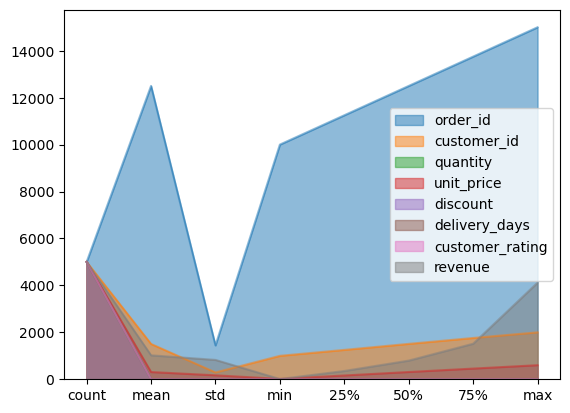

In [8]:
df.describe().plot(kind='area',stacked=False)

In [9]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [11]:
#Counts how many orders occurred in each month.
df['month'] = df['order_date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df['month'] = pd.Categorical(
    df['month'],
    categories=month_order,
    ordered=True
)

df['month'].value_counts().sort_index()

month
January      434
February     395
March        434
April        420
May          434
June         420
July         434
August       434
September    399
October      403
November     390
December     403
Name: count, dtype: int64

In [12]:
#This code is used to find how many orders you received in each year.
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year 
df['year'].value_counts()

year
2024    366
2028    366
2032    366
2022    365
2023    365
2025    365
2026    365
2027    365
2029    365
2030    365
2031    365
2033    365
2034    365
2035    252
Name: count, dtype: int64

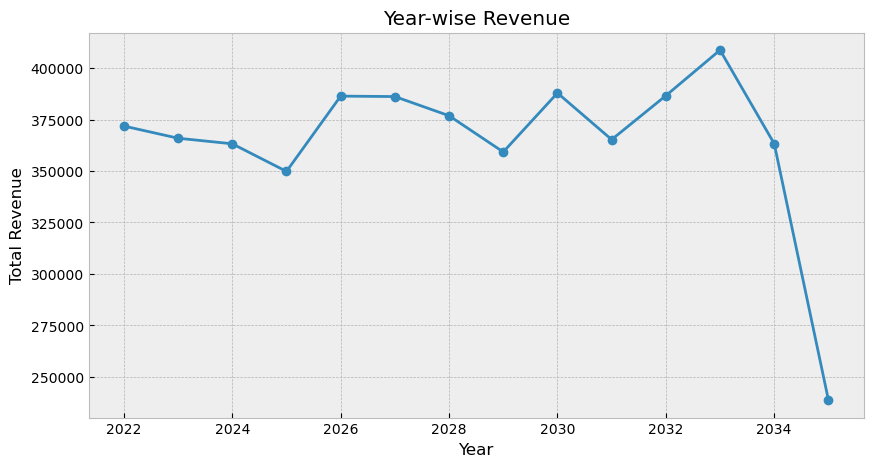

In [14]:
yearly_revenue = df.groupby('year')['revenue'].sum()

yearly_revenue.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Year-wise Revenue')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

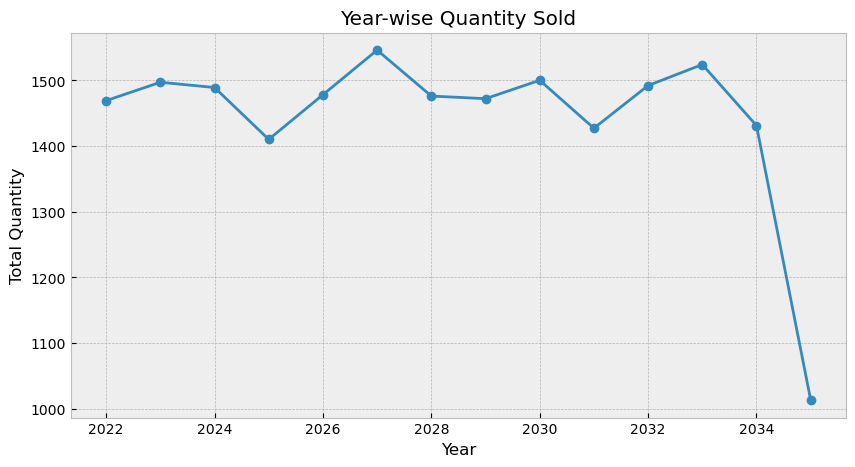

In [15]:
yearly_quantity = df.groupby('year')['quantity'].sum()

yearly_quantity.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Year-wise Quantity Sold')
plt.xlabel('Year')
plt.ylabel('Total Quantity')
plt.grid(True)
plt.show()

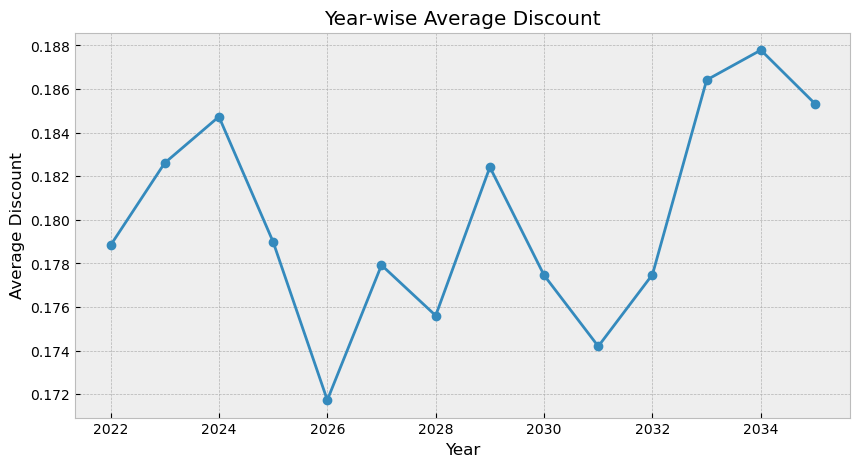

In [16]:
yearly_discount = df.groupby('year')['discount'].mean()

yearly_discount.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Year-wise Average Discount')
plt.xlabel('Year')
plt.ylabel('Average Discount')
plt.grid(True)
plt.show()

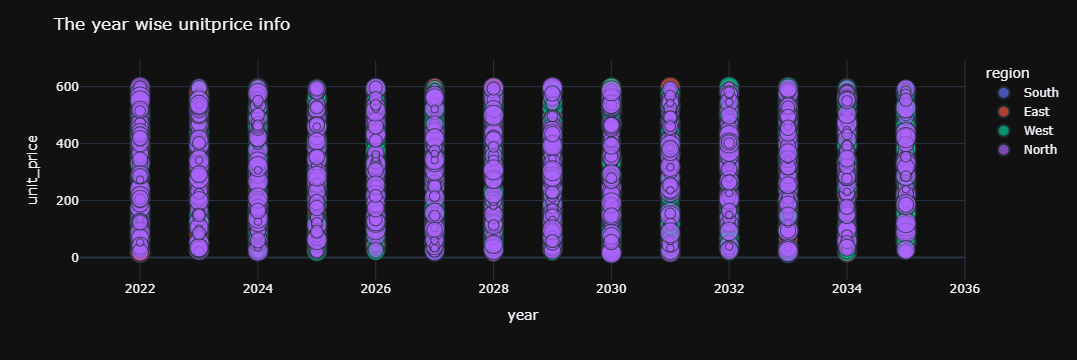

In [17]:
fig = px.scatter(
    df,
    x='year',
    y='unit_price',
    size='quantity',
    color='region'
)

fig.update_layout(
    title='The year wise unitprice info',
    template='plotly_dark'
)

fig.show()

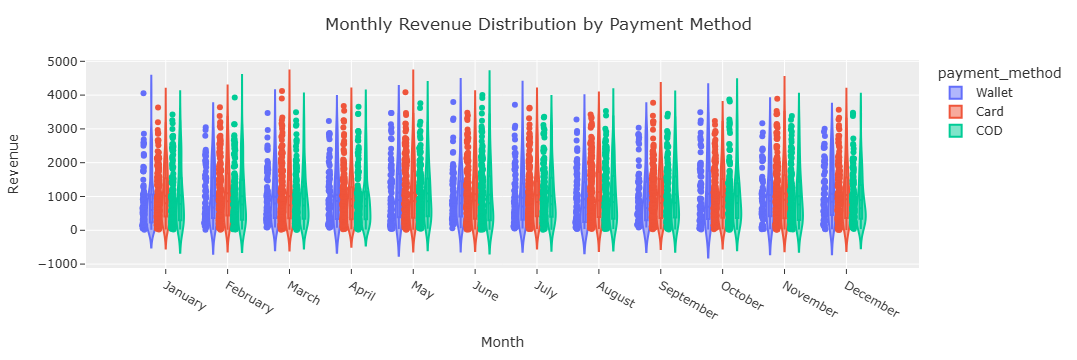

In [26]:
fig = px.violin(
    df,
    x='month',
    y='revenue',
    color='payment_method',
    box=True,
    points='all',
    hover_data=['region', 'quantity', 'unit_price']
)

fig.update_layout(
    title='Monthly Revenue Distribution by Payment Method',
    template='ggplot2',
    xaxis_title='Month',
    yaxis_title='Revenue'
)

fig.update_traces(meanline_visible=True)

fig.show()

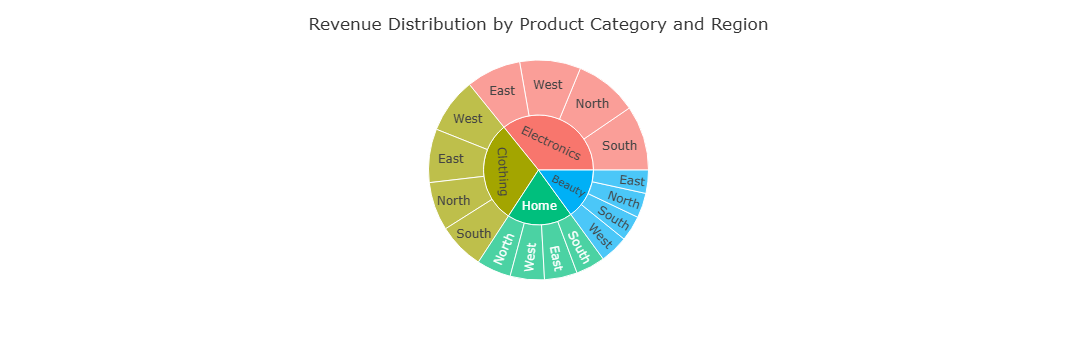

In [27]:
fig = px.sunburst(
    df,
    path=['product_category', 'region'],
    values='revenue'
)

fig.update_layout(
    title='Revenue Distribution by Product Category and Region',
    template='ggplot2'
)

fig.show()

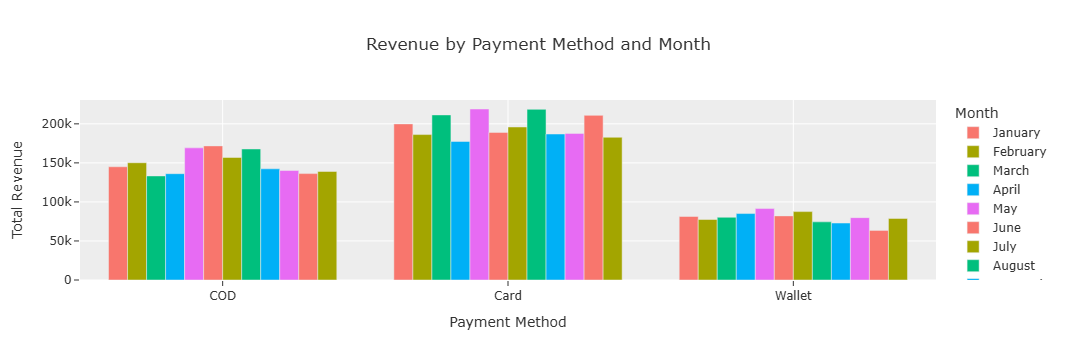

In [30]:
# Calculate total revenue by payment method and month
revenue_summary = (
    df.groupby(['payment_method', 'month'], observed=True)['revenue']
      .sum()
      .reset_index()
)

# Create the chart
fig = px.bar(
    revenue_summary,
    x='payment_method',
    y='revenue',
    color='month',
    barmode='group',
    title='Revenue by Payment Method and Month',
    template='ggplot2'
)

fig.update_layout(
    xaxis_title='Payment Method',
    yaxis_title='Total Revenue',
    legend_title='Month'
)

fig.show()

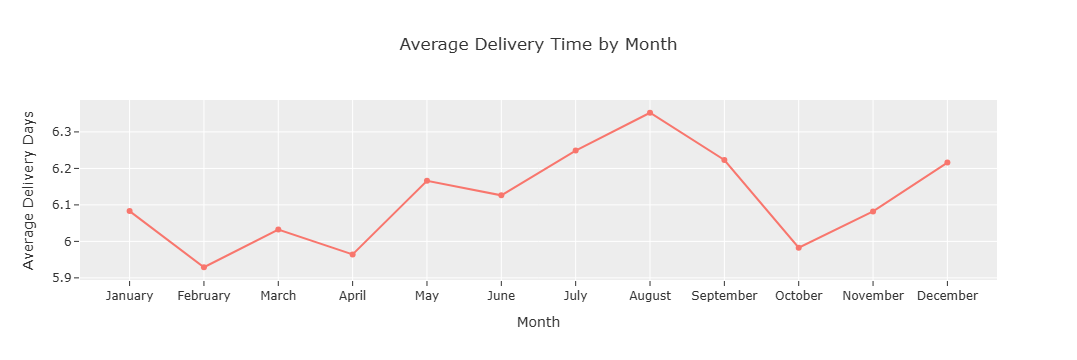

In [32]:
monthly_delivery = (
    df.groupby('month', observed=True)['delivery_days']
      .mean()
      .reset_index()
)
fig = px.line(
    monthly_delivery,
    x='month',
    y='delivery_days',
    markers=True,
    title='Average Delivery Time by Month',
    template='ggplot2'
)

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Average Delivery Days'
)

fig.show()

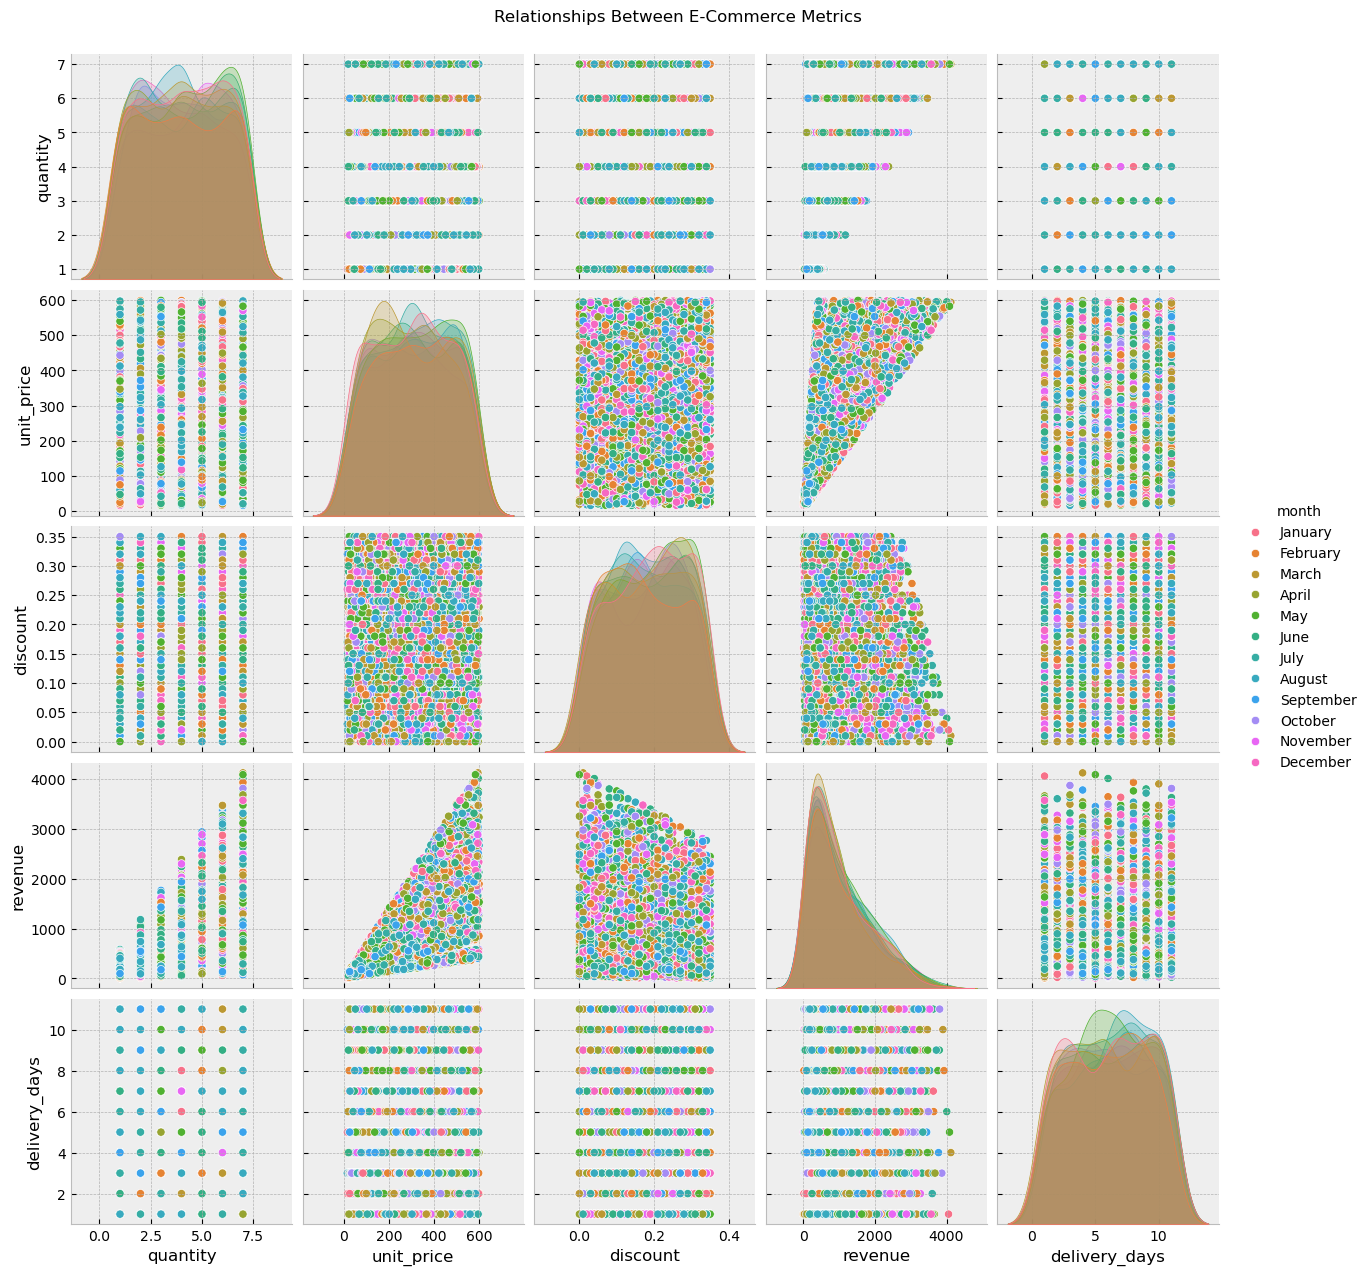

In [34]:
g = sns.pairplot(
    data=df,
    vars=[
        'quantity',
        'unit_price',
        'discount',
        'revenue',
        'delivery_days'
    ],
    hue='month'
)

g.fig.suptitle(
    'Relationships Between E-Commerce Metrics',
    y=1.02
)

plt.show()

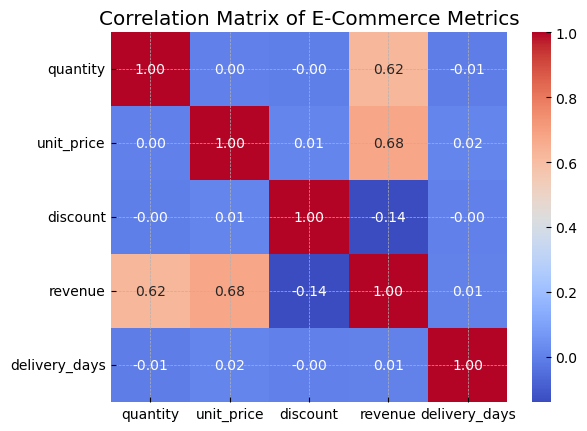

In [35]:
corr = df[
    ['quantity', 'unit_price', 'discount', 'revenue', 'delivery_days']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of E-Commerce Metrics')
plt.show()

In [36]:
#Top 10 customers by revenue
top_customers_revenue = (
    df.groupby('customer_id')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers_revenue

,customer_id,revenue
0,1663,17680.69
1,1955,16265.15
2,1675,15036.46
3,1276,15023.71
4,1647,14894.97
5,1804,14330.98
6,1193,14151.65
7,1836,14110.78
8,1957,13956.95
9,1735,13146.25


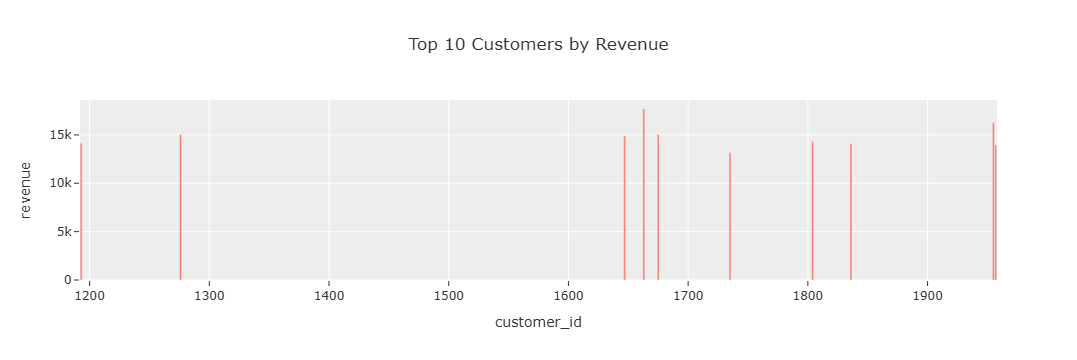

In [37]:
#customers generate the most revenue
fig = px.bar(
    top_customers_revenue,
    x='customer_id',
    y='revenue',
    title='Top 10 Customers by Revenue',
    template='ggplot2'
)

fig.show()

In [38]:
#Top customers by order count
top_customers_orders = (
    df.groupby('customer_id')['order_id']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name='order_count')
)


top_customers_orders

,customer_id,order_count
0,1663,14
1,1098,12
2,1112,12
3,1957,12
4,1935,12
5,1928,12
6,1669,12
7,1038,12
8,1612,11
9,1658,11
